In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
img = cv2.imread(r'C:\Users\hp\Desktop\1.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [4]:
# img_canny = cv2.Canny(img_gray, 200, 300, apertureSize=3)
img_canny = cv2.Laplacian(img_gray, -1)

46379

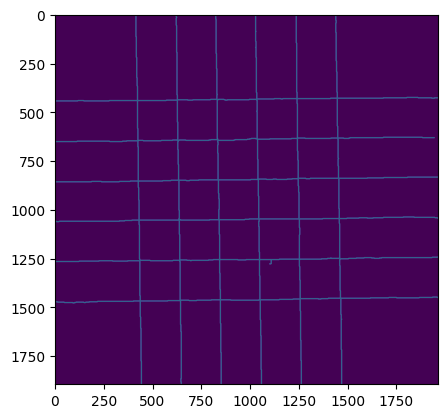

In [5]:
_c = img_canny.copy()
_c[img_canny>=img_canny.max()//3] = 255
plt.imshow(_c)
np.count_nonzero(_c == 255)

In [6]:
# care = img_canny==255
care = _c == 255

In [7]:
positions = np.where(care) # 返回元组，第一个矩阵储存行即y坐标， 第二个矩阵储存x坐标

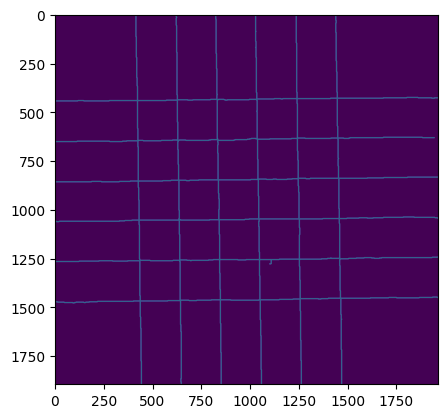

In [8]:
# 验证position是否正确
_iu = np.zeros_like(img_canny, dtype=np.uint8)
for x, y in zip(positions[0], positions[1]):
    _iu[x][y] = 255
plt.imshow(_iu)

In [9]:
# 把x坐标放前面 # [nums, x, y]格式
positions_np = np.concatenate([positions[1][..., np.newaxis], positions[0][..., np.newaxis]], axis=1) 

0.14683103561401367


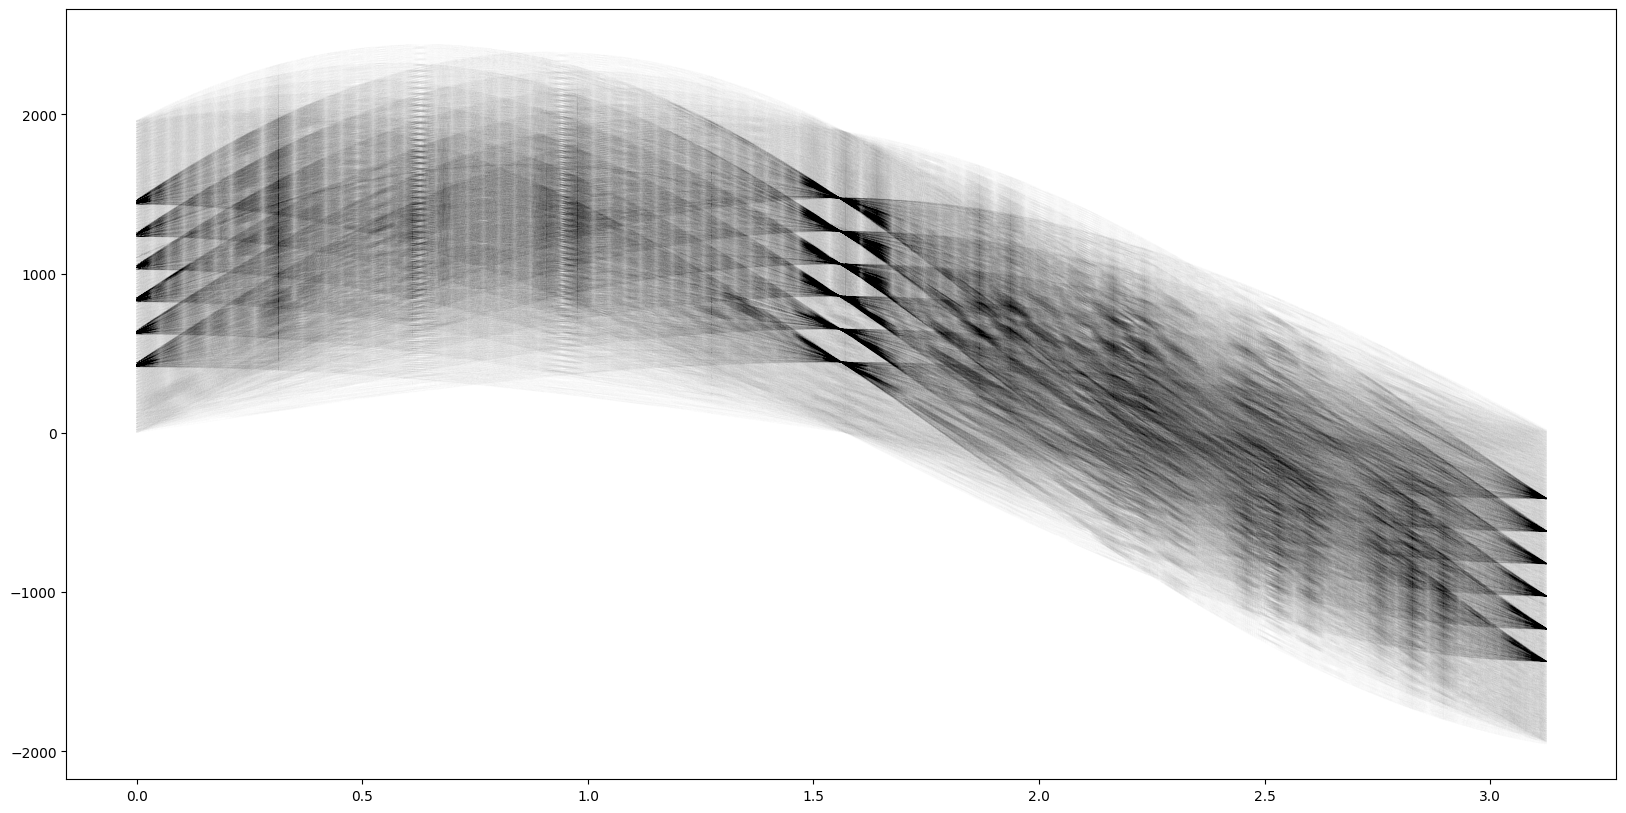

In [10]:
# 极坐标系到霍夫空间
plt.figure(figsize=(20,10))
_ax = plt.subplot(1,1,1)
# _xrange = np.linspace(0, np.pi, 100)
import time
t1 = time.time()
thetas=np.deg2rad(np.arange(0,180))
cos_t = np.cos(thetas)[...,np.newaxis]
sin_t = np.sin(thetas)[...,np.newaxis] # [180, 1]
rho_np = positions_np[:,0]*cos_t + positions_np[:,1]*sin_t # [180, nums]
print(time.time()-t1)
for _i in range(0, positions_np.shape[0]):
    # _pt = positions_np[_i]
    # _x, _y = _pt[0], _pt[1]
    # _yrange = _x*np.cos(_xrange) + _y* np.sin(_xrange)
    # _ax.plot(_xrange, _yrange, 'k-',alpha=0.5, linewidth=0.001)
    _ax.plot(thetas, rho_np[:, _i], 'k-',alpha=0.5, linewidth=0.001)
    
plt.show()

In [11]:
# 霍夫变换
thetas=np.deg2rad(np.arange(0,180))
cos_t = np.cos(thetas)[...,np.newaxis]
sin_t = np.sin(thetas)[...,np.newaxis] # [180, 1]
rho_np = positions_np[:,0]*cos_t + positions_np[:,1]*sin_t # [180, nums], nums个点对应180个角度的rho
rho_np_int = np.ceil(rho_np)

In [12]:
# for _i in range(180):
#     print(np.unique(rho_np_int[_i]).shape)
for _i in range(180*13352):
    a = 1+1

In [13]:
from collections import Counter

In [22]:
Counter(rho_np_int[0])

Counter({555.0: 3,
         210.0: 8,
         209.0: 7,
         30.0: 1,
         212.0: 4,
         12.0: 3,
         252.0: 6,
         265.0: 7,
         238.0: 5,
         695.0: 17,
         696.0: 11,
         274.0: 3,
         600.0: 28,
         502.0: 25,
         792.0: 9,
         309.0: 55,
         310.0: 60,
         308.0: 20,
         406.0: 49,
         503.0: 16,
         313.0: 68,
         599.0: 9,
         407.0: 73,
         205.0: 6,
         405.0: 4,
         116.0: 10,
         598.0: 1,
         25.0: 1,
         794.0: 16,
         387.0: 1,
         791.0: 6,
         793.0: 38,
         596.0: 2,
         504.0: 60,
         111.0: 9,
         601.0: 20,
         214.0: 7,
         697.0: 9,
         27.0: 2,
         142.0: 5,
         157.0: 3,
         311.0: 128,
         408.0: 50,
         409.0: 117,
         412.0: 33,
         698.0: 43,
         74.0: 2,
         219.0: 5,
         73.0: 1,
         304.0: 6,
         305.0: 5,
         35.0:

In [23]:
voteDict = {}
lines_num = 6
for _i, _ang in enumerate(thetas):
    _rho_1 = rho_np[_i]
    _rho_vote = Counter(_rho_1)
    voteDict[str(_ang)] = _rho_vote

In [16]:
_a = voteDict.keys()
# print(list(_a))
print(voteDict[list(_a)[0]].most_common(50))

[(311.0, 128), (409.0, 117), (319.0, 84), (314.0, 83), (407.0, 73), (313.0, 68), (415.0, 65), (310.0, 60), (504.0, 60), (418.0, 56), (309.0, 55), (408.0, 50), (312.0, 50), (406.0, 49), (417.0, 48), (317.0, 47), (698.0, 43), (416.0, 43), (315.0, 40), (510.0, 39), (793.0, 38), (316.0, 37), (513.0, 37), (701.0, 36), (412.0, 33), (318.0, 31), (410.0, 30), (600.0, 28), (506.0, 27), (502.0, 25), (320.0, 25), (411.0, 24), (413.0, 24), (609.0, 24), (611.0, 24), (603.0, 23), (414.0, 22), (602.0, 21), (507.0, 21), (514.0, 21), (308.0, 20), (601.0, 20), (796.0, 19), (604.0, 19), (608.0, 19), (695.0, 17), (704.0, 17), (512.0, 17), (802.0, 17), (503.0, 16)]


In [17]:
type(str(voteDict[list(_a)[0]].most_common(50)[0][0]))
float(str(voteDict[list(_a)[0]].most_common(50)[0][0]))

311.0

In [26]:
_a = voteDict.keys()
offset = 30
lines_num = 12
line_dict = {}
_aa = voteDict[list(_a)[0]].most_common(50) # 已经是降序排列了
line_dict[str(_aa[0][0])] = [0]

for i in range(1, len(_aa)):
    _vote_rho = str(_aa[i][0])
    _keys = line_dict.keys()
    _keys = list(_keys)
    # print(_keys)
    
    _flag1 = False
    for _key in _keys:
        _diff = float(_key) - float(_vote_rho)
        if abs(_diff) <= offset:
            line_dict[_key].append(_diff)
            _flag1 = True
            break
    if _flag1 == True:
        continue
    else:
        if len(_keys)<lines_num:
            line_dict[_vote_rho] = [0]


In [30]:
print(list(line_dict.keys()))

['443.0', '383.0', '503.0', '571.0', '625.0', '687.0']


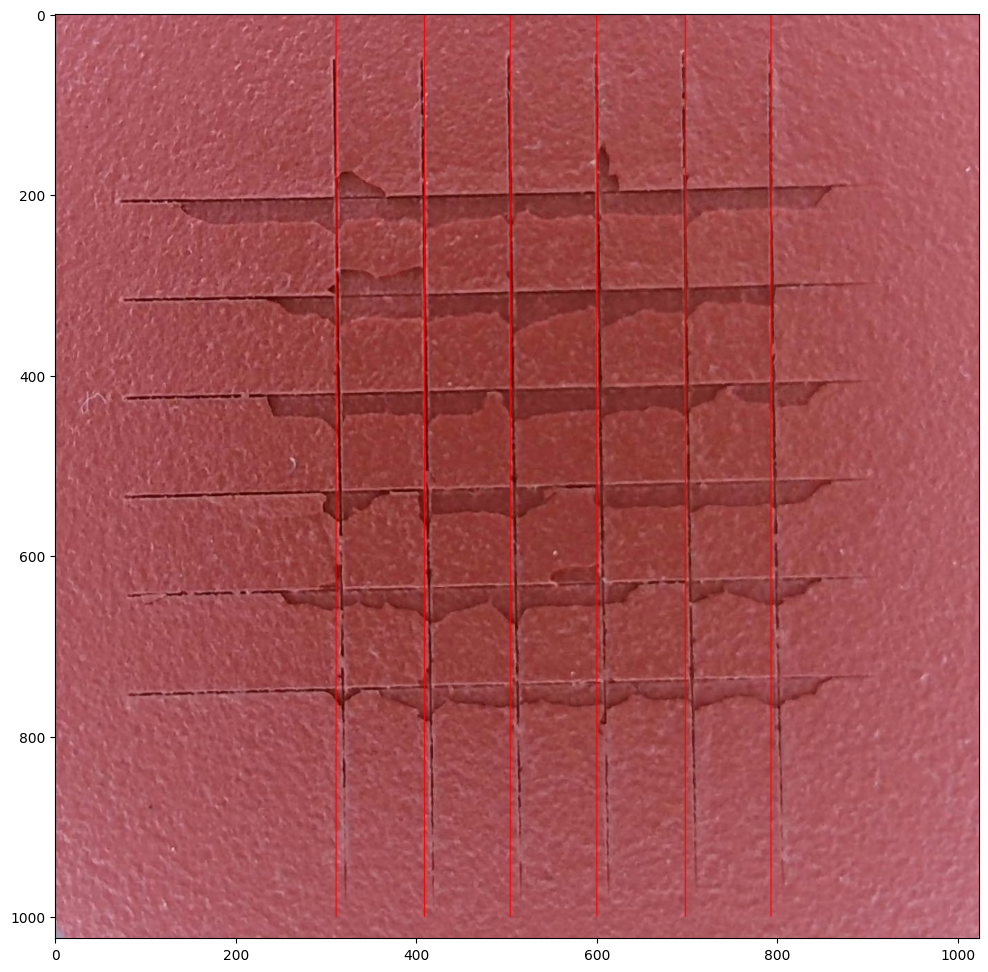

In [27]:
_img = img.copy()
for _item in list(line_dict.keys()):
    _rho = float(_item)
    _theta = 0
    a = np.math.cos(_theta)
    b = np.math.sin(_theta)
    x0 = a*_rho
    y0 = b*_rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(_img, pt1, pt2, (0,0,255), 1, cv2.LINE_AA)
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB))